# Libs

In [1]:
import cdsapi, os, yaml, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from typing import List, Dict, Union
from pathlib import Path

from loaders import GFS_loader, ERA5_loader, Merger
from configs import Constant, ERA_const, GFS_const
from plot_data import Plotter
from data_prepoc import Vars


# Configs

In [2]:
const = Constant()
gfs_const = GFS_const()
era_const = ERA_const()

In [3]:
const.start_date

Timestamp('2025-10-09 17:54:58.370418')

In [4]:
TODAY = const.today

# Load data

## ERA5

In [5]:
era_loader = ERA5_loader()
era_loader.remove_tmpfs()
era_loader.load()

2026-01-07 17:54:58,393 | INFO     | [FACT_ERA] Removed temporary file: /opt/airflow/app/data/datasets/fact/era_tmp_files/era5_2026_01_07_polar_vortex_2025.nc
2026-01-07 17:54:58,394 | INFO     | [FACT_ERA] Removed temporary file: /opt/airflow/app/data/datasets/fact/era_tmp_files/era5_2026_01_07_polar_vortex_2026.nc
2026-01-07 17:54:58,395 | DEBUG    | [ERA5_loader] - load :: {2025: [10, 11, 12], 2026: [1]}
2026-01-07 17:54:58,396 | INFO     | [FACT_ERA] Initializing CDS API client
2026-01-07 17:54:59,251 | INFO     | [FACT_ERA] Connected to CDS API OK
2026-01-07 17:54:59,252 | INFO     | [FACT_ERA] Start downloading: /opt/airflow/app/data/datasets/fact/era_tmp_files/era5_2026_01_07_polar_vortex_2025.nc
2026-01-07 17:54:59,627 INFO Request ID is 0bbebea3-6608-4548-9443-c35fc748546c
2026-01-07 17:54:59,760 INFO status has been updated to accepted
2026-01-07 17:55:13,568 INFO status has been updated to running
2026-01-07 17:55:18,688 INFO status has been updated to successful
2026-01-07 

In [6]:
era_data = era_loader.merge()
era_data

2026-01-07 17:57:11,566 | INFO     | [FACT_ERA] Opening 2 ERA NetCDF files
2026-01-07 17:57:21,495 | INFO     | [FACT_ERA] ERA dataset written to /opt/airflow/app/data/datasets/fact/era_data_2026_01_07.nc


<xarray.Dataset> Size: 588MB
Dimensions:         (valid_time: 94, pressure_level: 2, latitude: 181,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 752B 2025-10-01 ... 2026-01-02
  * pressure_level  (pressure_level) float64 16B 100.0 10.0
  * latitude        (latitude) float64 1kB 90.0 89.75 89.5 ... 45.5 45.25 45.0
  * longitude       (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    number          int64 8B 0
    expver          (valid_time) <U4 2kB '0001' '0001' '0001' ... '0005' '0005'
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 196MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 196MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 196MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-06T11:27 GRIB to CDM+CF via cfgrib-0.9.1...

## GFS data

In [7]:
gfs_loader = GFS_loader()

### Fact

In [8]:
# gfs_loader.remove_fact_tmpfs()

In [9]:
gfs_loader.load_fact()

2026-01-07 17:57:21,533 | INFO     | [FACT_GFS] 2026-01-02 .. 2026-01-07 cycle=00Z f000
2026-01-07 17:57:21,534 | INFO     | [FACT_GFS] skip exists: /opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260102_00z_f000.grib2
2026-01-07 17:57:21,535 | INFO     | [FACT_GFS] skip exists: /opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260103_00z_f000.grib2
2026-01-07 17:57:21,536 | INFO     | [FACT_GFS] skip exists: /opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260104_00z_f000.grib2
2026-01-07 17:57:21,536 | INFO     | [FACT_GFS] skip exists: /opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260105_00z_f000.grib2
2026-01-07 17:57:21,537 | INFO     | [FACT_GFS] skip exists: /opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260106_00z_f000.grib2
2026-01-07 17:57:21,538 | INFO     | [FACT_GFS] skip exists: /opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260107_00z_f000.grib2
2026-01-07 17:57:21,538 | INFO     | [FACT_GFS] end loading


In [10]:
gfs_fact = gfs_loader.merge_fact_tmpfs()
gfs_fact

Ignoring index file '/opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260102_00z_f000.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260103_00z_f000.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260104_00z_f000.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260105_00z_f000.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260106_00z_f000.grib2.5b7b6.idx' incompatible with GRIB file
Ignoring index file '/opt/airflow/app/data/datasets/fact/gfs_tmp_files/gfs_20260107_00z_f000.grib2.5b7b6.idx' incompatible with GRIB file
2026-01-07 17:57:24,304 | INFO     | [FACT_GFS] merge gfs fact data: /opt/airflow/app/data/datasets/fact/gfs_data.nc


<xarray.Dataset> Size: 224MB
Dimensions:        (valid_time: 6, isobaricInhPa: 3, latitude: 721,
                    longitude: 1440)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 48B 2026-01-02 ... 2026-01-07
  * isobaricInhPa  (isobaricInhPa) float64 24B 100.0 50.0 10.0
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    time           datetime64[ns] 8B 2026-01-02
Data variables:
    t              (valid_time, isobaricInhPa, latitude, longitude) float32 75MB ...
    u              (valid_time, isobaricInhPa, latitude, longitude) float32 75MB ...
    v              (valid_time, isobaricInhPa, latitude, longitude) float32 75MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-01-07T17:57 GRIB to CDM+CF via cfgrib-0.9.1...

### Forecast

In [11]:
gfs_loader.remove_forecast_tmpfs()

2026-01-07 17:57:24,324 | INFO     | [FORECAST_GFS] remove old tmp files


In [ ]:
gfs_loader.load_forecast()

2026-01-07 17:57:24,351 | INFO     | [FORECAST_GFS] init=2026-01-07 cycle=06Z f000..f336 step=6h
2026-01-07 17:57:24,353 | INFO     | [FORECAST_GFS]  download: f000-0:0
2026-01-07 17:57:28,419 | INFO     | [FORECAST_GFS]  download: f006-0:6
2026-01-07 17:57:32,685 | INFO     | [FORECAST_GFS]  download: f012-0:12
2026-01-07 17:57:36,868 | INFO     | [FORECAST_GFS]  download: f018-0:18
2026-01-07 17:57:41,581 | INFO     | [FORECAST_GFS]  download: f024-1:0
2026-01-07 17:57:45,736 | INFO     | [FORECAST_GFS]  download: f030-1:6
2026-01-07 17:57:50,374 | INFO     | [FORECAST_GFS]  download: f036-1:12
2026-01-07 17:57:55,129 | INFO     | [FORECAST_GFS]  download: f042-1:18
2026-01-07 17:57:59,140 | INFO     | [FORECAST_GFS]  download: f048-2:0
2026-01-07 17:58:03,123 | INFO     | [FORECAST_GFS]  download: f054-2:6
2026-01-07 17:58:07,791 | INFO     | [FORECAST_GFS]  download: f060-2:12
2026-01-07 17:58:12,311 | INFO     | [FORECAST_GFS]  download: f066-2:18
2026-01-07 17:58:16,500 | INFO   

: 

In [ ]:
gfs_forecast = gfs_loader.merge_forecast_tmpfs()
gfs_forecast

# Merge datasets

In [ ]:
merger = Merger()

In [ ]:
ds = merger.merge_datasets(
    era_fact_xds=era_data,
    gfs_fact_xds=gfs_fact,
    gfs_forecast_xds=gfs_forecast,
)
ds

2026-01-07 19:38:07,111 | INFO     | [MERGER] start merge data
2026-01-07 19:38:07,111 | DEBUG    | [MERGER] start prepare gfs
2026-01-07 19:38:12,292 | DEBUG    | [MERGER] end prepare gfs
2026-01-07 19:38:12,293 | DEBUG    | [MERGER] start prepare era
2026-01-07 19:38:12,293 | DEBUG    | [MERGER] end prepare era
2026-01-07 19:38:13,756 | INFO     | [MERGER] end merge data


<xarray.Dataset> Size: 707MB
Dimensions:         (valid_time: 113, pressure_level: 2, latitude: 181,
                     longitude: 1440)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 904B 2025-10-01 ... 2026-01-21
  * pressure_level  (pressure_level) float64 16B 100.0 10.0
  * latitude        (latitude) float64 1kB 90.0 89.75 89.5 ... 45.5 45.25 45.0
  * longitude       (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
Data variables:
    u               (valid_time, pressure_level, latitude, longitude) float32 236MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 236MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 236MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-06T11:27 GRIB to CDM+CF via cfgrib-0.9.1...

# Data analysis

In [ ]:
plotter = Plotter()
preproc = Vars()

In [ ]:
u_df = preproc.get_u60_df(ds)
t_df = preproc.get_t_df(ds)
eddy_df = preproc.get_eddy_hf_df(ds)

2026-01-07 19:38:13,941 | DEBUG    | Computing U(60N, 10 hPa) zonal mean
2026-01-07 19:38:13,943 | DEBUG    | U60 dataframe built successfully, shape=(113, 1)
2026-01-07 19:38:13,943 | DEBUG    | Computing T polar cap(lats[90, 60], 10 hPa) mean
2026-01-07 19:38:13,995 | DEBUG    | Temp dataframe built successfully, shape=(113, 2)


## U60

In [ ]:
u_df

,u
valid_time,
2025-10-01,10.643506
2025-10-02,11.168775
2025-10-03,12.278296
2025-10-04,13.201069
2025-10-05,11.997635
...,...
2026-01-17,21.557009
2026-01-18,23.817339
2026-01-19,27.287882


2026-01-07 19:38:14,175 | DEBUG    | Plotting 'u' | mean=False, q20/q80=False
2026-01-07 19:38:14,176 | DEBUG    | fill_between=True but 'mean' column — skipping mean line


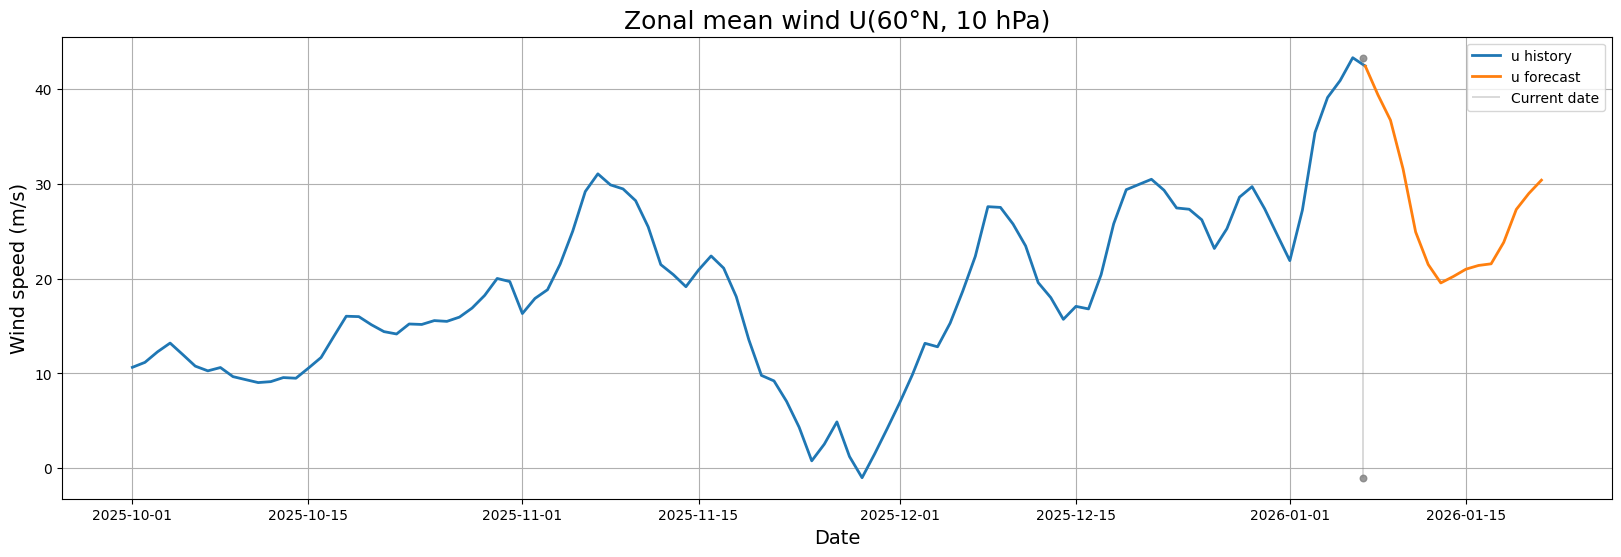

(<Figure size 2000x600 with 1 Axes>,
 <Axes: title={'center': 'Zonal mean wind U(60°N, 10 hPa)'}, xlabel='Date', ylabel='Wind speed (m/s)'>)

In [ ]:
plotter.plot_graph(
    u_df,
    var_name='u',
    ylabel="Wind speed (m/s)",
    xlabel="Date",
    title="Zonal mean wind U(60°N, 10 hPa)",
    show=True
)

## Temperature

In [ ]:
t_df

,t,t_C
date,,
2025-10-01,219.729995,-53.420005
2025-10-02,219.584653,-53.565347
2025-10-03,219.322559,-53.827441
2025-10-04,218.766127,-54.383873
2025-10-05,217.869683,-55.280317
...,...,...
2026-01-17,213.888749,-59.261251
2026-01-18,213.291995,-59.858005
2026-01-19,210.824730,-62.325270


2026-01-07 19:38:14,255 | DEBUG    | Plotting 't_C' | mean=False, q20/q80=False
2026-01-07 19:38:14,256 | DEBUG    | fill_between=True but 'mean' column — skipping mean line


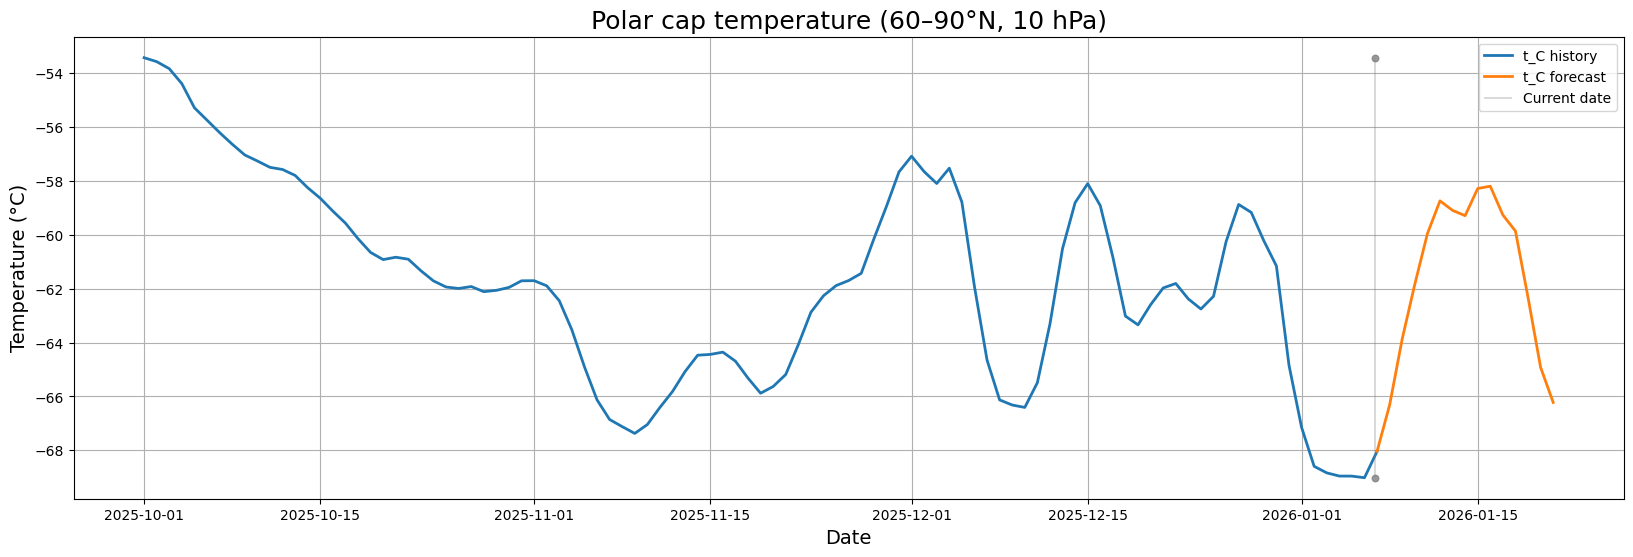

(<Figure size 2000x600 with 1 Axes>,
 <Axes: title={'center': 'Polar cap temperature (60–90°N, 10 hPa)'}, xlabel='Date', ylabel='Temperature (°C)'>)

In [ ]:
plotter.plot_graph(
    t_df,
    var_name='t_C',
    ylabel="Temperature (°C)",
    xlabel="Date",
    title="Polar cap temperature (60–90°N, 10 hPa)",
    show=True
)

## Eddy HF

In [ ]:
eddy_df

,hf,hf_40,doy,mean_hf,mean,std,q20,q80,hf_40_anomaly
time,,,,,,,,,
2025-11-09,18.128575,9.717301,313,9.336140,9.276530e-16,1.280357,-0.820883,0.831346,0.381161
2025-11-10,24.209837,10.156518,314,9.484484,1.381611e-15,1.304312,-0.738041,0.833132,0.672035
2025-11-11,17.080678,10.415895,315,9.619413,3.947460e-17,1.320804,-0.809037,0.852066,0.796482
2025-11-12,12.602674,10.562197,316,9.757518,-4.342206e-16,1.325961,-0.869436,1.023825,0.804678
2025-11-13,13.882979,10.725931,317,9.883333,2.960595e-16,1.340998,-0.861847,0.997342,0.842598
...,...,...,...,...,...,...,...,...,...
2026-01-17,20.948962,19.334723,17,17.829313,-1.211152e-16,4.194322,-3.403652,3.910726,1.505410
2026-01-18,17.301687,19.136419,18,17.956032,2.543420e-15,4.296609,-3.633530,3.851495,1.180387
2026-01-19,12.134790,18.561859,19,18.083278,-1.130409e-15,4.388583,-3.744884,3.841593,0.478582


2026-01-07 19:38:14,322 | DEBUG    | Plotting 'hf_40_anomaly' | mean=True, q20/q80=True
2026-01-07 19:38:14,323 | DEBUG    | fill_between=True but 'mean' column — skipping mean line


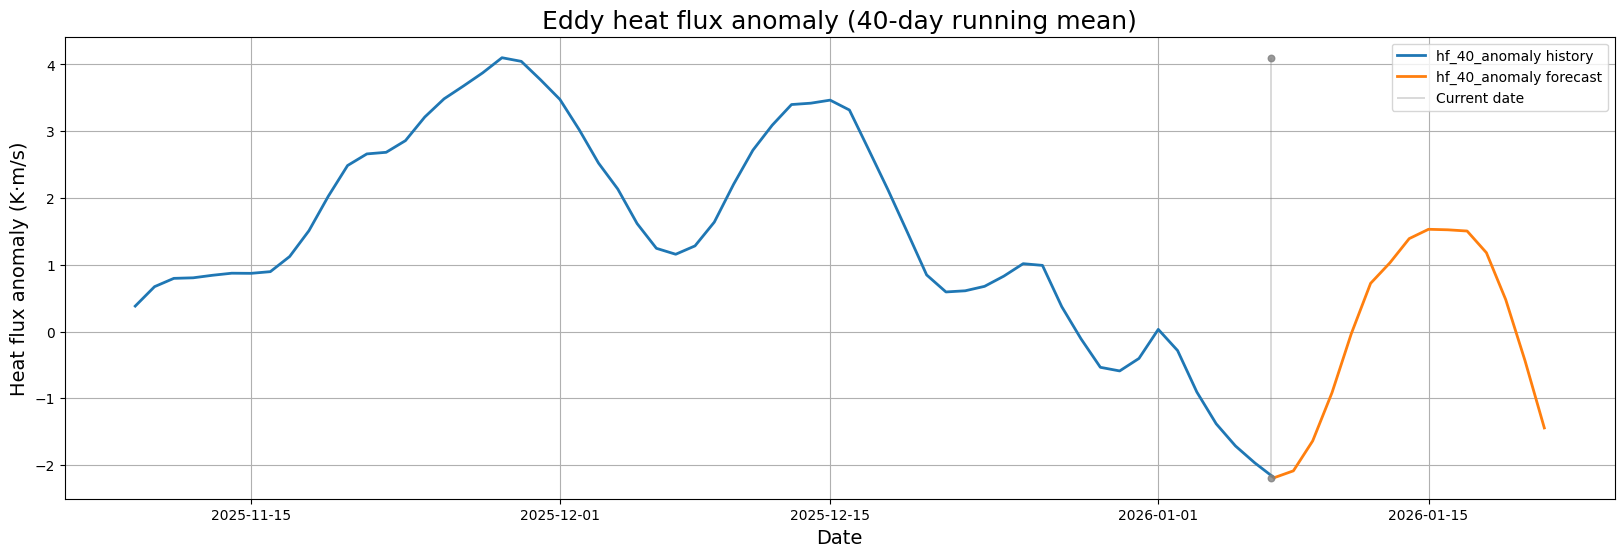

(<Figure size 2000x600 with 1 Axes>,
 <Axes: title={'center': 'Eddy heat flux anomaly (40-day running mean)'}, xlabel='Date', ylabel='Heat flux anomaly (K·m/s)'>)

In [ ]:
plotter.plot_graph(
    eddy_df,
    var_name='hf_40_anomaly',
    ylabel="Heat flux anomaly (K·m/s)",
    xlabel="Date",
    title="Eddy heat flux anomaly (40-day running mean)",
    show=True,
    show_today=True,
)

# Garbage

In [25]:
from pathlib import Path

def print_tree(root: Path, prefix=""):
    print(prefix + root.name + "/")
    for path in sorted(root.iterdir()):
        if path.is_dir():
            print_tree(path, prefix + "    ")

root = Path("/Users/artem/Documents/Zerich/polar_vortex/project_polar_vortex")
print_tree(root)


project_polar_vortex/
    airflow/
        dags/
            __pycache__/
    app/
        data/
            climatology/
            datasets/
                fact/
                    era_tmp_files/
                    gfs_tmp_files/
                forecast/
                    gfs_tmp_files/
            datasets_1/
                fact/
                    era_tmp_files/
                    gfs_tmp_files/
                forecast/
                    gfs_tmp_files/
            logs/
            logs_1/
        tools/
            __pycache__/
            loaders/
